In [1]:
import numpy as np
import pytest
import pyccl as ccl
from pyccl import CCLWarning

from pyccl.pk2d import Pk2D
from pyccl.correlations import correlation

import matplotlib
import matplotlib.pyplot as plt

In [40]:
#set up cosmology

COSMO = ccl.Cosmology(
    Omega_c=0.26507647072945384,
    Omega_b=0.0495,
    Omega_k=0,
    h=0.6732,
    w0=-1,
    wa=0,
    A_s=2.1/1e9,
    n_s=0.96605,
    m_nu=0.06,
    Neff=3.046,
    mass_split='single',
    transfer_function='boltzmann_camb',
    matter_power_spectrum='camb',
    extra_parameters = {"camb": {"halofit_version": "takahashi",
                                 'AccuracyBoost': 1.0,
                                 'kmax':15,
                                 'dark_energy_model': 'ppf',
                                 'accurate_massive_neutrino_transfer': False,
                                 'k_per_logint': 15,
                                 }}
    )
h=0.6732

#set up lens and source sample

srcs_nzs = np.loadtxt('./cocoa/Cocoa/projects/roman_fourier/data/fiducial.nz')
lens_nzs = np.loadtxt('./cocoa/Cocoa/projects/roman_fourier/data/lsst_lens_4cosmolike.nz')

z_srcs = srcs_nzs[:,0]+0.005
srcs_nz = srcs_nzs[:,1:]
z_lens = lens_nzs[:,0]+0.005
lens_nz = lens_nzs[:,1:]

srcs = []
lens = []
nsrcs = 8
nlens = 10
gbias =  [1.09,1.15,1.21,1.27,1.33,1.40,1.46,1.53,1.60,1.67]
ggl_exclude = []

for i in range(nsrcs):
    srcs.append(ccl.WeakLensingTracer(COSMO, dndz=(z_srcs, srcs_nz[:,i]), has_shear=True, n_samples=400))
for i in range(nlens):
    lens.append(ccl.NumberCountsTracer(COSMO, dndz=(z_lens, lens_nz[:,i]), bias=(z_lens,np.ones_like(z_lens)*gbias[i]), has_rsd=False, n_samples=400))

### Radial kernel

$C_\ell^{ab} = \frac{2}{2\ell+1}\int_0^\infty dk P_\delta(k,z_\ell)\tilde{\Delta}_\ell^a(k)\tilde{\Delta}_\ell^b(k)$

$\tilde{\Delta}_\ell^D(k) = p_z(z_\ell)b(z_\ell)H(z_\ell)$

### Limber integration

- CCL default integration method is initializing a redshift grid (or the $\chi$ grid or the $k$ grid, they are the same thing under Limber) calculate all these components of integrand over the grid and do a Akima spline integration.

- CosmoLike explicitly build an integrand function for the Limber integration and do a Gauss-Legendre Quadrature

Therefore to make a fair comparison, we employ CCL's internal spline grid to COCOA, compute the kernel and compare


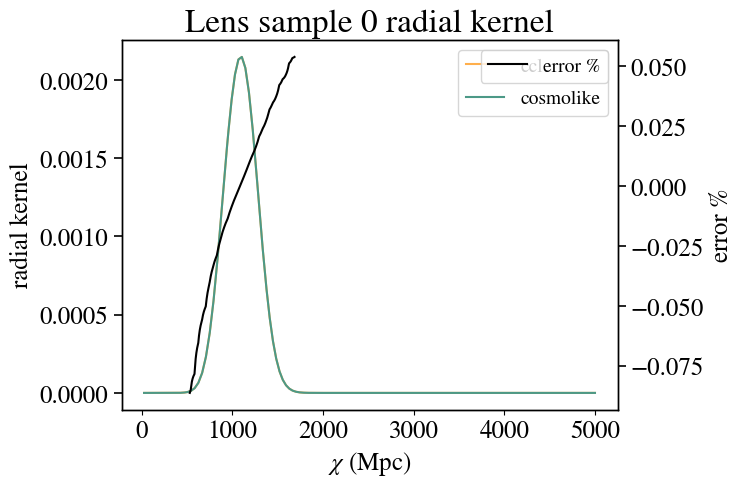

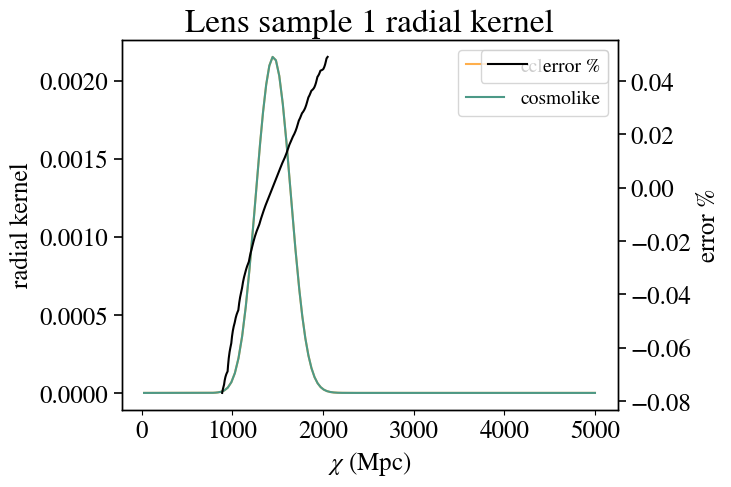

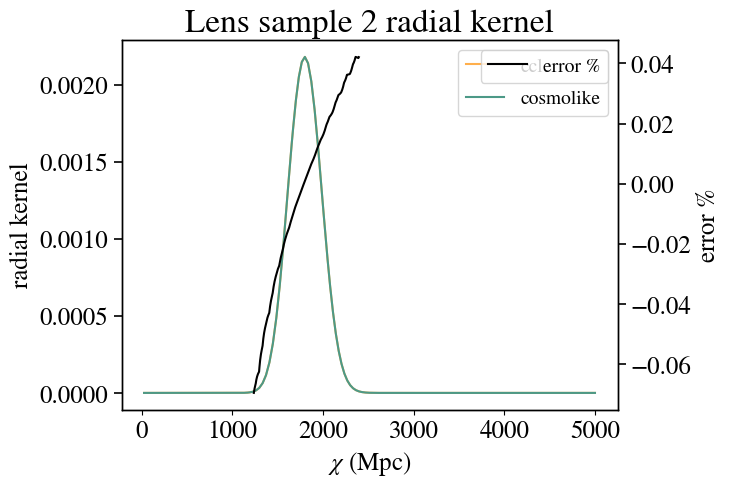

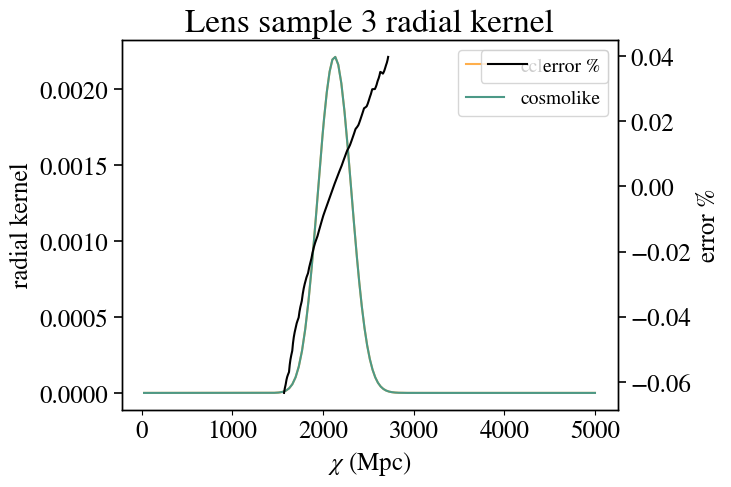

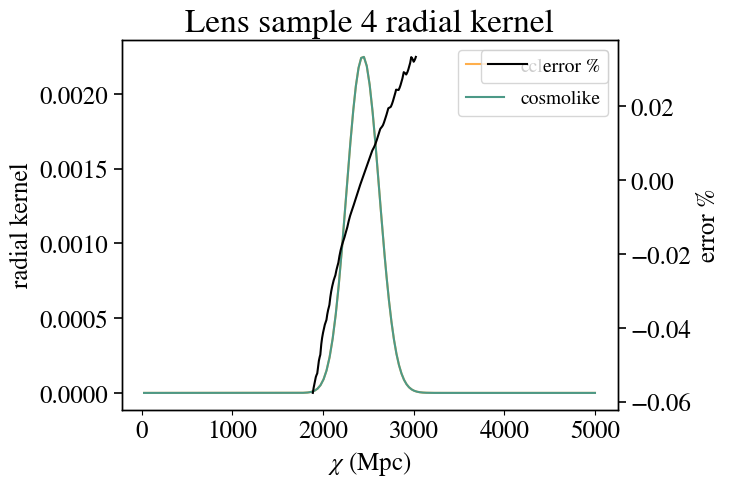

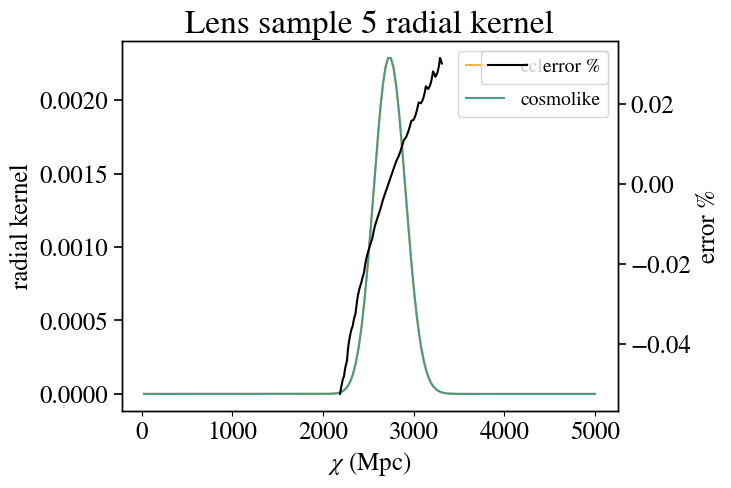

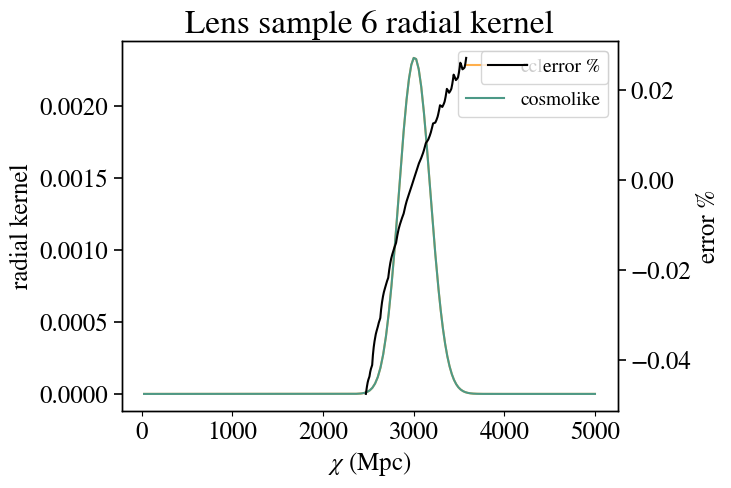

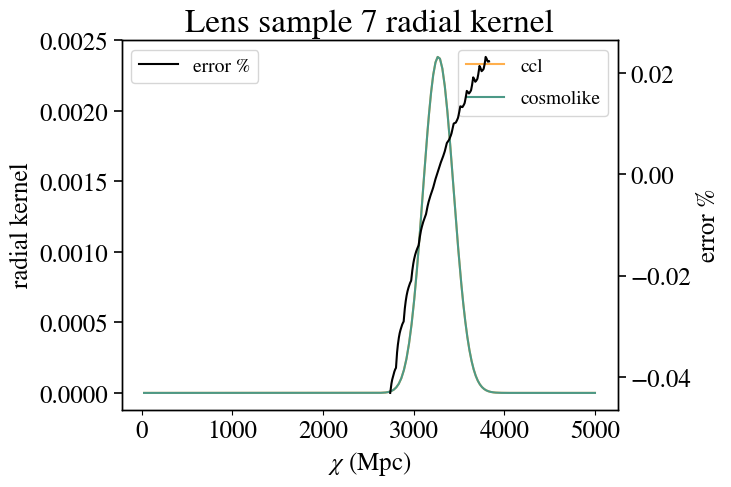

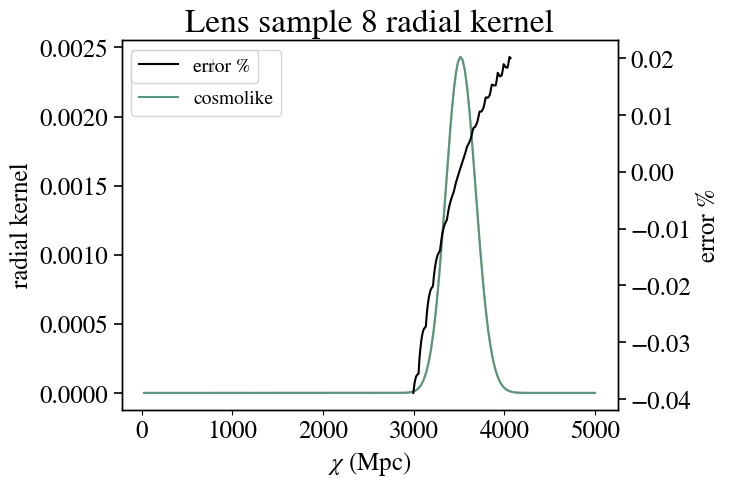

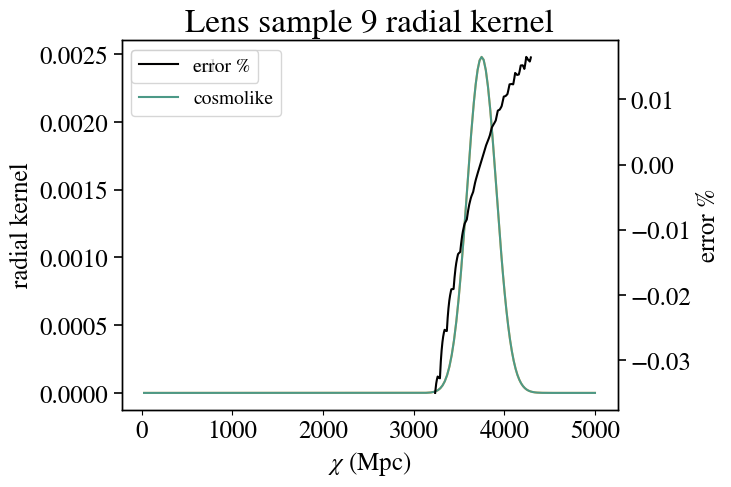

In [41]:
from scipy.interpolate import interp1d
filepath = './cocoa/Cocoa/projects/roman_fourier/chains/roman_setup0_evaluate/'
chis_cosmolike = np.loadtxt(filepath+'chi_of_radial_kernel.txt')
kernel_cosmolike = np.loadtxt(filepath+'radial_kernel.txt')
chis = np.linspace(25, 5000, 5000)

for i in range(nlens):
    
    chis_ccl = lens[i].get_kernel()[1][0]
    kernel_ccl = lens[i].get_kernel()[0][0]
    f_ccl = interp1d(chis_ccl, kernel_ccl)
    f_cosmolike = interp1d(chis_cosmolike, kernel_cosmolike[i,:])

    ys_ccl = f_ccl(chis)
    ys_cosmolike = f_cosmolike(chis)

    fig, ax1 = plt.subplots()
    ax1.plot(chis, ys_ccl, color='#FFAF4C', label='ccl')
    ax1.plot(chis, ys_cosmolike, color='#4C9987', label='cosmolike')
    ax1.set_ylabel('radial kernel')
    ax1.set_xlabel(r'$\chi$ (Mpc)')
    ax1.legend()
        
    ax2 = ax1.twinx()
    greater0 = (ys_ccl>1e-5)
    ax2.plot(chis[greater0], (ys_cosmolike[greater0]-ys_ccl[greater0])/ys_ccl[greater0]*100, color='k', label='error %')
    ax2.set_ylabel('error %')
    ax2.legend()

    plt.title(f'Lens sample {i} radial kernel')
    plt.show()

    
    

### Conclusion

CCL and CosmoLike's radial kernel are aligned and all error are controlled below 0.1%. The error is linear increase with comoving distance which probably comes from the chi-z table used for interpolation, however we don't investigate it here because the error is small enough.

### Modification

One thing we want to emphsize that CCL and CosmoLike are using different normalization factor for redshift distribution, the one of CCL integrates redshift distribution between bin centers, i.e there is a half-bar contraction at the boundary, while CosmoLike does a full integration between bin edges. However since no evident bias appears for the radial kernel of the first and last tomographic bin, we decide not to fix it here.

In [23]:
# GENERAL PLOT OPTIONS
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams['mathtext.rm'] = 'Bitstream Vera Sans'
matplotlib.rcParams['mathtext.it'] = 'Bitstream Vera Sans:italic'
matplotlib.rcParams['mathtext.bf'] = 'Bitstream Vera Sans:bold'
matplotlib.rcParams['xtick.bottom'] = True
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['xtick.top'] = False
matplotlib.rcParams['ytick.right'] = False
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['ytick.major.size'] = 6
matplotlib.rcParams['ytick.major.width'] = 1.2
matplotlib.rcParams['ytick.minor.size'] = 3
matplotlib.rcParams['ytick.minor.width'] = 0.8
matplotlib.rcParams['axes.edgecolor'] = 'black'
matplotlib.rcParams['axes.linewidth'] = '1.0'
matplotlib.rcParams['axes.labelsize'] = 18
matplotlib.rcParams['axes.titlesize'] = 24
matplotlib.rcParams['axes.grid'] = True
matplotlib.rcParams['grid.linewidth'] = '0.0'
matplotlib.rcParams['grid.alpha'] = '0.18'
matplotlib.rcParams['grid.color'] = 'lightgray'
matplotlib.rcParams['legend.labelspacing'] = 0.77
matplotlib.rcParams['legend.fontsize'] = 14
matplotlib.rcParams['legend.title_fontsize'] = 18
matplotlib.rcParams['savefig.bbox'] = 'tight'
matplotlib.rcParams['savefig.dpi'] = 300